# Eksperimen SML - Titanic Survival Prediction

**Nama:** Fathir

**Dataset:** Titanic Dataset

## 1. Perkenalan Dataset

Titanic Dataset berisi data penumpang kapal Titanic dan apakah mereka **selamat atau tidak**.

- **Jumlah sampel:** 891
- **Jumlah fitur:** 7 (setelah seleksi)
- **Jumlah kelas:** 2 (survived: 0=Tidak, 1=Ya)
- **Task:** Klasifikasi Biner

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import os, warnings
warnings.filterwarnings('ignore')
print('Library berhasil di-import!')

Library berhasil di-import!


## 3. Memuat Dataset

In [2]:
df = sns.load_dataset('titanic')
print(f'Dataset shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['survived'].value_counts())
raw_dir = os.path.join('..', 'titanic_raw')
os.makedirs(raw_dir, exist_ok=True)
df.to_csv(os.path.join(raw_dir, 'titanic_raw.csv'), index=False)
print(f'\nData mentah disimpan ke: {raw_dir}/titanic_raw.csv')
df.head(10)

Dataset shape: (891, 15)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Data mentah disimpan ke: ..\titanic_raw/titanic_raw.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 4. Exploratory Data Analysis (EDA)

In [3]:
# 4.1 Info & Statistik
print('=== Info Dataset ===')
print(df.dtypes)
print(f'\n=== Statistik Deskriptif ===')
df.describe()

=== Info Dataset ===
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

=== Statistik Deskriptif ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# 4.2 Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()}')

=== Missing Values ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Total missing: 869


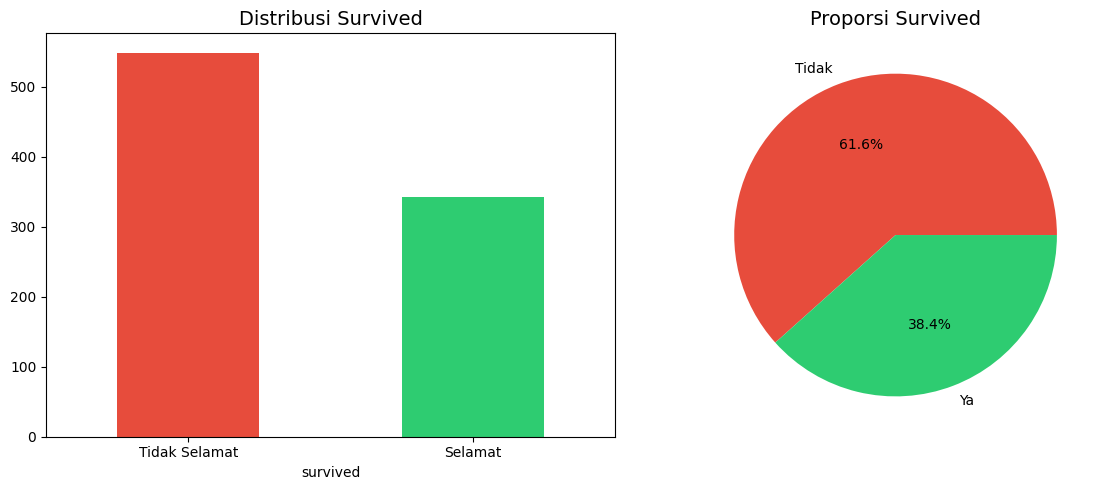

In [5]:
# 4.3 Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#2ecc71']
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Survived', fontsize=14)
axes[0].set_xticklabels(['Tidak Selamat', 'Selamat'], rotation=0)
df['survived'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, labels=['Tidak','Ya'])
axes[1].set_title('Proporsi Survived', fontsize=14)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

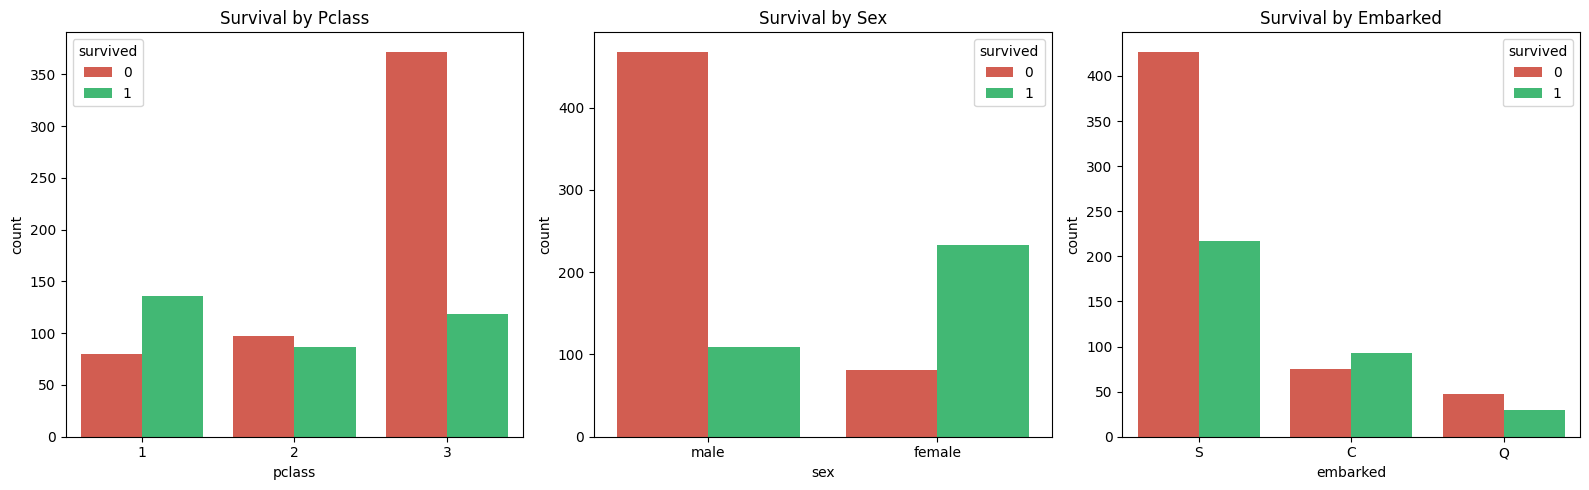

In [6]:
# 4.4 Survival by Class & Gender
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x='pclass', hue='survived', ax=axes[0], palette=colors)
axes[0].set_title('Survival by Pclass')
sns.countplot(data=df, x='sex', hue='survived', ax=axes[1], palette=colors)
axes[1].set_title('Survival by Sex')
sns.countplot(data=df, x='embarked', hue='survived', ax=axes[2], palette=colors)
axes[2].set_title('Survival by Embarked')
plt.tight_layout()
plt.show()

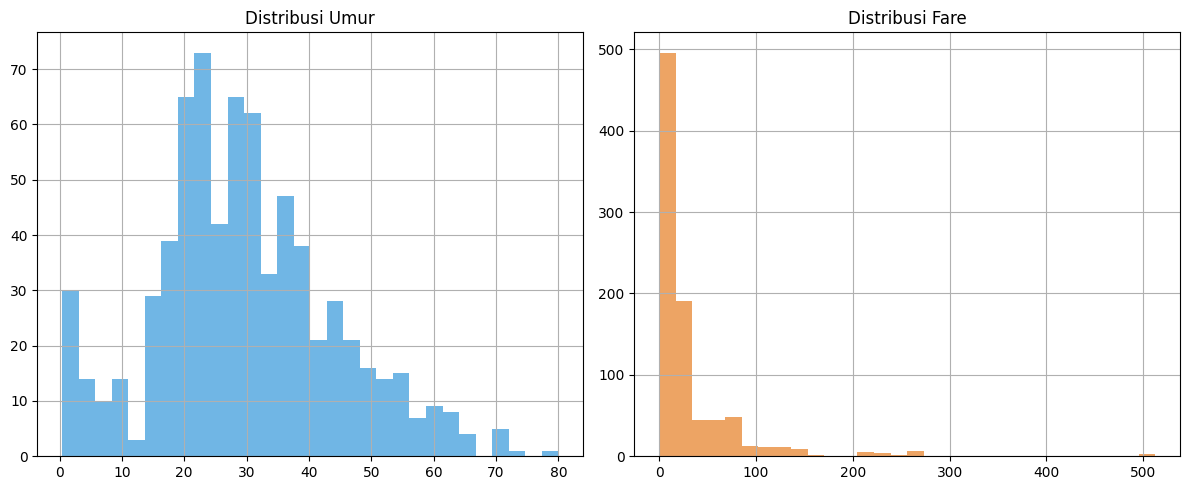

In [7]:
# 4.5 Histogram Age & Fare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['age'].hist(bins=30, ax=axes[0], color='#3498db', alpha=0.7)
axes[0].set_title('Distribusi Umur')
df['fare'].hist(bins=30, ax=axes[1], color='#e67e22', alpha=0.7)
axes[1].set_title('Distribusi Fare')
plt.tight_layout()
plt.show()

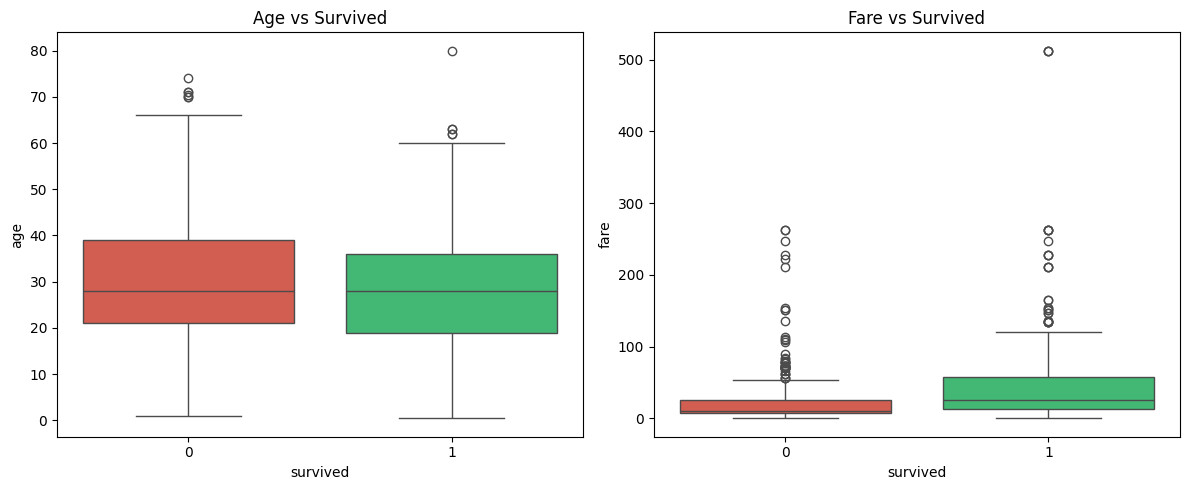

In [8]:
# 4.6 Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='survived', y='age', ax=axes[0], palette=colors)
axes[0].set_title('Age vs Survived')
sns.boxplot(data=df, x='survived', y='fare', ax=axes[1], palette=colors)
axes[1].set_title('Fare vs Survived')
plt.tight_layout()
plt.show()

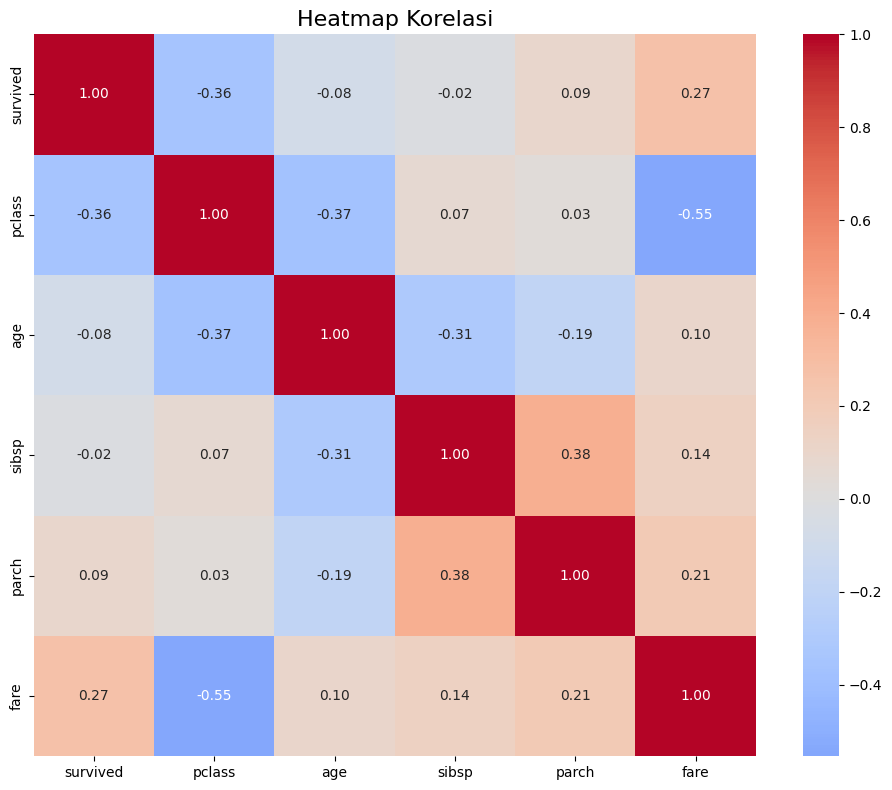

In [9]:
# 4.7 Heatmap Korelasi
plt.figure(figsize=(10, 8))
numeric_df = df[['survived','pclass','age','sibsp','parch','fare']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Heatmap Korelasi', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Preprocessing

In [10]:
# 5.1 Seleksi fitur
df_clean = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].copy()
print(f'Fitur dipilih: {list(df_clean.columns)}')
print(f'Shape: {df_clean.shape}')

Fitur dipilih: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Shape: (891, 8)


In [11]:
# 5.2 Handle Missing Values
print('Missing sebelum:')
print(df_clean.isnull().sum()[df_clean.isnull().sum()>0])
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
print(f'\nMissing sesudah: {df_clean.isnull().sum().sum()}')

Missing sebelum:
age         177
embarked      2
dtype: int64

Missing sesudah: 0


In [12]:
# 5.3 Encoding Kategorikal
df_clean['sex'] = LabelEncoder().fit_transform(df_clean['sex'])
df_clean['embarked'] = LabelEncoder().fit_transform(df_clean['embarked'])
print('Encoding selesai')
df_clean.head()

Encoding selesai


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [13]:
# 5.4 Feature Scaling
num_cols = ['age', 'fare', 'sibsp', 'parch']
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
print('StandardScaler diterapkan')
df_clean.describe().round(4)

StandardScaler diterapkan


,survived,pclass,sex,age,sibsp,parch,fare,embarked
count,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,0.6476,0.0000,0.0000,0.0000,0.0000,1.5365
std,0.4866,0.8361,0.4780,1.0006,1.0006,1.0006,1.0006,0.7915
min,0.0000,1.0000,0.0000,-2.2242,-0.4745,-0.4737,-0.6484,0.0000
25%,0.0000,2.0000,0.0000,-0.5657,-0.4745,-0.4737,-0.4891,1.0000
50%,0.0000,3.0000,1.0000,-0.1046,-0.4745,-0.4737,-0.3574,2.0000
75%,1.0000,3.0000,1.0000,0.4333,0.4328,-0.4737,-0.0242,2.0000
max,1.0000,3.0000,1.0000,3.8916,6.7842,6.9741,9.6672,2.0000


In [14]:
# 5.5 Train-Test Split
X = df_clean.drop(columns=['survived'])
y = df_clean['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training: {X_train.shape}, Test: {X_test.shape}')
print(f'Target train: {y_train.value_counts().to_dict()}')
print(f'Target test: {y_test.value_counts().to_dict()}')

Training: (712, 7), Test: (179, 7)
Target train: {0: 439, 1: 273}
Target test: {0: 110, 1: 69}


In [15]:
# 5.6 Simpan data preprocessed
prep_dir = os.path.join('.', 'titanic_preprocessing')
os.makedirs(prep_dir, exist_ok=True)
df_clean.to_csv(os.path.join(prep_dir, 'titanic_preprocessed.csv'), index=False)
print(f'Data preprocessed disimpan: {prep_dir}/titanic_preprocessed.csv')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Data preprocessed disimpan: .\titanic_preprocessing/titanic_preprocessed.csv
Shape: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,2
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,0
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,2
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,2
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,2


## Kesimpulan

1. **Titanic Dataset** memiliki 891 sampel dengan binary classification (survived/not survived)
2. **Missing values** pada age (177) dan embarked (2) telah ditangani
3. **Encoding** diterapkan pada fitur kategorikal (sex, embarked)
4. **StandardScaler** diterapkan pada fitur numerik
5. Data siap untuk tahap modelling